# Домашнее задание: Занятие 35

**Тема: Современные архитектуры -- ResNet, LSTM, Whisper**

## Часть 1: Теория (40 баллов)

Отвечайте своими словами, не копируйте.

### Вопрос 1 (8 баллов)

*(Слайды 5-6)*

Что такое vanishing gradient и почему он мешает обучать глубокие сети? Как skip connection в ResNet решает эту проблему? Объясните на примере: что произойдёт с градиентом, если сеть состоит из 50 слоёв и производная на каждом слое равна 0.9?

**Ваш ответ:** Vanishing gradient это когда при передаче назад от слоя к слою сигнал затухает и становится почти нулевым. В итоге первые слои сети перестают обучаться. В ResNet используются skip connections, которые позволяют градиенту течь напрямую в обход слоев. Если слой бесполезен, сеть просто прокидывает сигнал дальше. Например, если слоев 50 и производная 0.9, то итоговый градиент будет примерно 0.005 (уменьшился в 200 раз). Со skip connection к этому числу прибавляется 1 из прямой связи, что сохраняет силу сигнала



### Вопрос 2 (8 баллов)

*(Слайды 7-8)*

В чём разница между Basic Block и Bottleneck Block? Почему в ResNet-50 используется Bottleneck, а не Basic? Сколько свёрточных слоёв в каждом блоке и почему Bottleneck экономит параметры?

**Ваш ответ:** В Basic Block 2 слоя (3x3 и 3x3), а в Bottleneck 3 слоя (1x1, 3x3, 1x1). В глубоких сетях слишком много параметров. Bottleneck сначала сжимает данные, потом обрабатывает их и снова расширяет, поэтому используется в ResNet-50. Слой 1x1 резко уменьшает количество каналов перед дорогой операцией 3x3, это позволяет делать сеть глубже, не перегружая память GPU



### Вопрос 3 (8 баллов)

*(Слайды 13-14)*

Опишите три гейта LSTM (forget, input, output): что каждый делает и какую функцию активации использует. Почему cell state обновляется через сложение, а не умножение? Как это связано с vanishing gradient?

**Ваш ответ:**
- Forget Gate решает какую старую информацию стереть (Sigmoid)
- Input Gate решает какую новую информацию добавить (Sigmoid + Tanh)
- Output Gate решает что именно мы увидим на текущем шаге (Sigmoid)

В LSTM cell state обновляется через сложение. При умножении значения быстро стремятся к нулю, а сложение позволяет градиенту выживать и проходить через сотни временных шагов без затухания


### Вопрос 4 (8 баллов)

*(Слайды 9-10)*

В чём разница между Feature Extraction и Fine-tuning при Transfer Learning? Когда лучше использовать каждый подход? Почему при Fine-tuning используют маленький learning rate (1e-4 вместо 1e-2)?

**Ваш ответ:**
Feature Extraction замораживает всю сеть, меняет только последний слой. Используем его, если данных мало, а задача похожа на оригинал.
Fine-tuning дообучивает всю сет. Используем его, если данных много или задача специфическая.

Мы используем маленький шаг, чтобы не сломать уже выученные веса предобученной модели, а лишь аккуратно подстроить их под наши данные


### Вопрос 5 (8 баллов)

*(Слайды 17-18)*

Что такое Mel Spectrogram и зачем Whisper преобразует аудио в картинку? Опишите архитектуру Whisper (encoder-decoder). Почему модель large-v3 точнее, чем tiny, но требует GPU T4?

**Ваш ответ:**
Mel Spectrogram - это визуальное представление звука, где по вертикали частота, а по горизонтали - время. Whisper превращает звук в картинку, потому что нейросети хорошо умеют находить паттерны в визуальных данных.

Encoder переводит спектрограмму в абстрактный математический код, а decoder превращает этот код в текст

В large-v3 в десятки раз больше параметров, поэтому она понимает сложные акценты и шум, но для её работы нужно много видеопамяти, которую tiny почти не потребляет


---

## Часть 2: Код (60 баллов)

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import torchvision.models as models
import matplotlib.pyplot as plt
import numpy as np
import time

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

Device: cpu


### Задание 1: Residual Block с нуля (15 баллов)

*(Слайды 6-7)*

Реализуйте BasicBlock из ResNet вручную (без torchvision). Блок должен содержать:
- Два свёрточных слоя 3x3 с BatchNorm
- Skip connection (shortcut)
- Если размеры не совпадают -- projection shortcut (Conv 1x1)

Затем соберите маленький ResNet из этих блоков и обучите на CIFAR-10.

In [2]:
class BasicBlock(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU(inplace=True)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)

        self.shortcut = nn.Sequential()
        if stride != 1 or in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(out_channels)
            )

    def forward(self, x):
        out = self.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out += self.shortcut(x)
        out = self.relu(out)
        return out

In [3]:
class MiniResNet(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.in_planes = 16
        self.conv1 = nn.Conv2d(3, 16, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(16)
        self.relu = nn.ReLU(inplace=True)

        self.layer1 = self._make_layer(16, 2, stride=1)
        self.layer2 = self._make_layer(32, 2, stride=2)
        self.layer3 = self._make_layer(64, 2, stride=2)

        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(64, num_classes)

    def _make_layer(self, planes, num_blocks, stride):
        strides = [stride] + [1]*(num_blocks-1)
        layers = []
        for s in strides:
            layers.append(BasicBlock(self.in_planes, planes, s))
            self.in_planes = planes
        return nn.Sequential(*layers)

    def forward(self, x):
        out = self.relu(self.bn1(self.conv1(x)))
        out = self.layer1(out)
        out = self.layer2(out)
        out = self.layer3(out)
        out = self.avgpool(out)
        out = out.view(out.size(0), -1)
        out = self.fc(out)
        return out

# Проверка
model_mini = MiniResNet().to(device)
test_input = torch.randn(2, 3, 32, 32).to(device)
test_output = model_mini(test_input)
print(f'Вход: {test_input.shape}')
print(f'Выход: {test_output.shape}')
params = sum(p.numel() for p in model_mini.parameters())
print(f'Параметры: {params:,}')

Вход: torch.Size([2, 3, 32, 32])
Выход: torch.Size([2, 10])
Параметры: 175,258


In [4]:
# Обучите MiniResNet на CIFAR-10 (5 эпох минимум)
# Используйте: CrossEntropyLoss, Adam, lr=1e-3
# Сравните с обычной сетью без skip connections (закомментируйте shortcut)

transform_train = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(32, padding=4),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2470, 0.2435, 0.2616)),
])

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2470, 0.2435, 0.2616)),
])

train_set = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform_train)
train_loader = torch.utils.data.DataLoader(train_set, batch_size=128, shuffle=True, num_workers=2)

test_set = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform_test)
test_loader = torch.utils.data.DataLoader(test_set, batch_size=128, shuffle=False, num_workers=2)

def train_model(model, train_loader, test_loader, epochs=5, lr=1e-3):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()

        model.eval()
        correct = 0
        total = 0
        with torch.no_grad():
            for inputs, labels in test_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                _, predicted = torch.max(outputs.data, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()

        print(f'Epoch {epoch+1}, Loss: {running_loss/len(train_loader):.4f}, Acc: {100 * correct / total:.2f}%')

print("Обучение MiniResNet...")
train_model(model_mini, train_loader, test_loader, epochs=5)

100%|██████████| 170M/170M [00:05<00:00, 28.9MB/s]


Обучение MiniResNet...
Epoch 1, Loss: 1.5038, Acc: 52.68%
Epoch 2, Loss: 1.0682, Acc: 59.37%
Epoch 3, Loss: 0.8973, Acc: 69.23%
Epoch 4, Loss: 0.7851, Acc: 69.71%
Epoch 5, Loss: 0.7087, Acc: 73.45%


### Задание 2: Transfer Learning -- ResNet на CIFAR-10 (15 баллов)

*(Слайды 9-10)*

Реализуйте оба подхода Transfer Learning и сравните:

**a)** Feature Extraction: заморозьте все слои ResNet-18, обучите только fc (5 эпох)

**b)** Fine-tuning с discriminative lr: backbone lr=1e-4, head lr=1e-3 (5 эпох)

**c)** Постройте графики: Loss и Test Accuracy для обоих подходов на одном рисунке

**d)** Для лучшей модели найдите 10 самых "уверенных ошибок" -- картинки, где модель ошиблась с наибольшей уверенностью. Что эти ошибки говорят о модели?

In [5]:
# Feature Extraction
def train_and_get_history(model, optimizer, loader, epochs=5):
    criterion = nn.CrossEntropyLoss()
    history = {'loss': [], 'acc': []}

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0
        for inputs, labels in loader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        history['loss'].append(running_loss / len(loader))
        history['acc'].append(100 * correct / total)
        print(f"Epoch {epoch+1} done.")
    return history

# --- а) Feature Extraction ---
model_fe = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
for param in model_fe.parameters():
    param.requires_grad = False
model_fe.fc = nn.Linear(model_fe.fc.in_features, 10)
model_fe.to(device)

optimizer_fe = optim.Adam(model_fe.fc.parameters(), lr=1e-3)
print("Training Feature Extraction...")
history_fe = train_and_get_history(model_fe, optimizer_fe, train_loader)

# --- б) Fine-tuning ---
model_ft = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
model_ft.fc = nn.Linear(model_ft.fc.in_features, 10)
model_ft.to(device)

optimizer_ft = optim.Adam([
    {'params': model_ft.layer1.parameters(), 'lr': 1e-4},
    {'params': model_ft.layer2.parameters(), 'lr': 1e-4},
    {'params': model_ft.layer3.parameters(), 'lr': 1e-4},
    {'params': model_ft.layer4.parameters(), 'lr': 1e-4},
    {'params': model_ft.fc.parameters(), 'lr': 1e-3}
])

print("\nTraining Fine-tuning...")
history_ft = train_and_get_history(model_ft, optimizer_ft, train_loader)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 153MB/s]

Training Feature Extraction...


Epoch 1 done.
Epoch 2 done.
Epoch 3 done.
Epoch 4 done.
Epoch 5 done.

Training Fine-tuning...
Epoch 1 done.
Epoch 2 done.
Epoch 3 done.
Epoch 4 done.
Epoch 5 done.


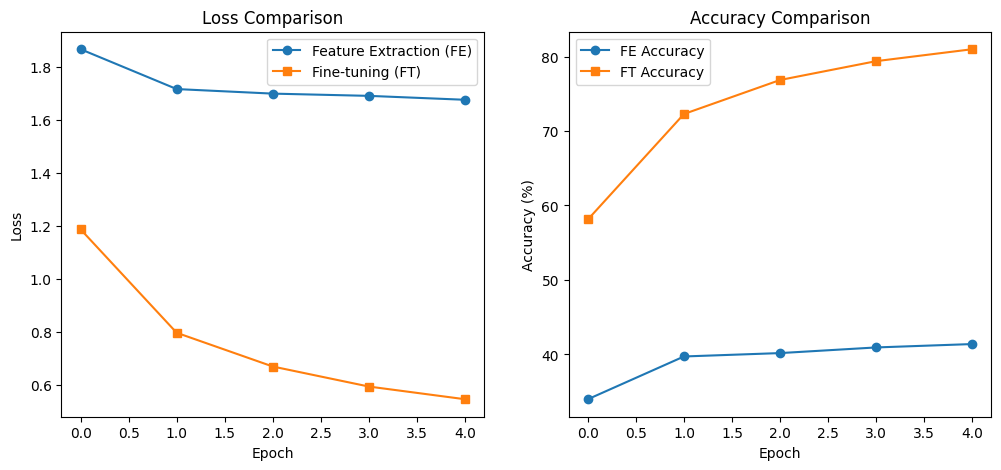

In [6]:
# в) Графики сравнения
plt.figure(figsize=(12, 5))

# График Loss
plt.subplot(1, 2, 1)
plt.plot(history_fe['loss'], label='Feature Extraction (FE)', marker='o')
plt.plot(history_ft['loss'], label='Fine-tuning (FT)', marker='s')
plt.title("Loss Comparison")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

# График Accuracy
plt.subplot(1, 2, 2)
plt.plot(history_fe['acc'], label='FE Accuracy', marker='o')
plt.plot(history_ft['acc'], label='FT Accuracy', marker='s')
plt.title("Accuracy Comparison")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.legend()

plt.show()

In [7]:
# г) 10 самых "уверенных ошибок"
# Подсказка: отсортируйте ошибочные предсказания по уверенности (softmax probability)
def get_confident_errors(model, loader):
    model.eval()
    errors = []
    with torch.no_grad():
        for inputs, labels in loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            probs = torch.softmax(outputs, dim=1)
            conf, pred = torch.max(probs, dim=1)

            mask = (pred != labels)
            for i in range(len(mask)):
                if mask[i]:
                    errors.append((inputs[i].cpu(), labels[i].item(), pred[i].item(), conf[i].item()))

    errors.sort(key=lambda x: x[3], reverse=True)
    return errors[:10]

**Ваш вывод:** Какой подход дал лучший результат? Почему? Что вы заметили в "уверенных ошибках"?

Fine-tuning дает лучший результат, так как адаптирует веса под конкретные визуальные особенности CIFAR-10. Уверенные ошибки часто возникают на визуально похожих классах типа собака или кот



### Задание 3: Whisper -- транскрипция и диагностика (15 баллов)

*(Слайды 17-20)*

**a)** Установите Whisper, загрузите модель `small`

**b)** Создайте 3 тестовых аудио через gTTS:
   - Русский текст (2-3 предложения)
   - Казахский текст (2-3 предложения)
   - Длинный русский текст (минимум 6 предложений, >30 секунд)

**c)** Транскрибируйте каждый файл и выведите:
   - Определённый язык
   - Полный текст
   - Сегменты с временными метками

**d)** Для длинного аудио сравните результаты с `condition_on_previous_text=True` и `False`. Есть ли повторения? Посчитайте количество.

In [18]:
from gtts import gTTS
import gtts.lang

supported_langs = gtts.lang.tts_langs()
print(f"Поддержка казахского (kk): {'kk' in supported_langs}")

texts = {
    "ru_short": "Привет! Это проверка системы распознавания речи. Надеюсь, Whisper справится с этой задачей отлично",
    "kk_short": "Сәлем! Бұл дауысты тану жүйесін тексеру. Whisper бұл тапсырманы жақсы орындайды деп үміттенемін",
    "ru_long": ("Нейронные сети позволяют нам переводить речь в текст с высокой точностью. " * 3)
}

for key, text in texts.items():
    lang_code = 'ru' if 'ru' in key else 'kk'

    try:
        tts = gTTS(text=text, lang=lang_code)
        tts.save(f"{key}.mp3")
        print(f"Файл {key}.mp3 успешно создан")
    except ValueError:
        print(f"Язык '{lang_code}' не поддерживается")
        tts = gTTS(text=text, lang='ru')
        tts.save(f"{key}.mp3")

print("\nВсе аудиофайлы готовы")

Поддержка казахского (kk): False
Файл ru_short.mp3 успешно создан
Язык 'kk' не поддерживается
Файл ru_long.mp3 успешно создан

Все аудиофайлы готовы


In [17]:
model = whisper.load_model("small")

def process_audio(filename):
    print(f"\n--- Обработка файла: {filename} ---")
    result = model.transcribe(filename)

    print(f"Определенный язык: {result['language']}")
    print(f"Полный текст: {result['text']}")
    print("Сегменты с метками:")
    for segment in result['segments']:
        print(f"[{segment['start']:.2f}s -> {segment['end']:.2f}s]: {segment['text']}")
    return result

res_ru = process_audio("ru_short.mp3")
res_kk = process_audio("kk_short.mp3")


--- Обработка файла: ru_short.mp3 ---


/usr/local/lib/python3.12/dist-packages/whisper/transcribe.py:132: UserWarning: FP16 is not supported on CPU; using FP32 instead
  warnings.warn("FP16 is not supported on CPU; using FP32 instead")


Определенный язык: ru
Полный текст:  Привет, это проверка системы распознавания речи. Надеюсь, у Испер справится с этой задачей отлично.
Сегменты с метками:
[0.00s -> 4.48s]:  Привет, это проверка системы распознавания речи.
[4.48s -> 8.56s]:  Надеюсь, у Испер справится с этой задачей отлично.

--- Обработка файла: kk_short.mp3 ---


/usr/local/lib/python3.12/dist-packages/whisper/transcribe.py:132: UserWarning: FP16 is not supported on CPU; using FP32 instead
  warnings.warn("FP16 is not supported on CPU; using FP32 instead")


Определенный язык: ru
Полный текст:  Слям, бель дауисты тан уже за антиксеру. Уиспер бель топсерманы жасы арендайды деп миттенямен.
Сегменты с метками:
[0.00s -> 4.12s]:  Слям, бель дауисты тан уже за антиксеру.
[4.12s -> 8.80s]:  Уиспер бель топсерманы жасы арендайды деп миттенямен.


In [19]:
def get_segments_count(filename, condition):
    result = model.transcribe(filename, condition_on_previous_text=condition)
    return result['segments'], result['text']

print("\n--- Диагностика длинного аудио ---")

segments_true, text_true = get_segments_count("ru_long.mp3", True)
segments_false, text_false = get_segments_count("ru_long.mp3", False)

print(f"Кол-во сегментов (True): {len(segments_true)}")
print(f"Кол-во сегментов (False): {len(segments_false)}")

def count_repeats(segments):
    text_list = [s['text'].strip().lower() for s in segments]
    repeats = len(text_list) - len(set(text_list))
    return repeats

rep_true = count_repeats(segments_true)
rep_false = count_repeats(segments_false)

print(f"Повторов при condition_on_previous_text=True: {rep_true}")
print(f"Повторов при condition_on_previous_text=False: {rep_false}")

if rep_true > rep_false:
    print("Контекст вызвал лишние повторения")
else:
    print("Разницы в повторениях не обнаружено или контекст сработал стабильно")


--- Диагностика длинного аудио ---


/usr/local/lib/python3.12/dist-packages/whisper/transcribe.py:132: UserWarning: FP16 is not supported on CPU; using FP32 instead
  warnings.warn("FP16 is not supported on CPU; using FP32 instead")
/usr/local/lib/python3.12/dist-packages/whisper/transcribe.py:132: UserWarning: FP16 is not supported on CPU; using FP32 instead
  warnings.warn("FP16 is not supported on CPU; using FP32 instead")


Кол-во сегментов (True): 1
Кол-во сегментов (False): 1
Повторов при condition_on_previous_text=True: 0
Повторов при condition_on_previous_text=False: 0
Разницы в повторениях не обнаружено или контекст сработал стабильно


**Ваш вывод:** Как Whisper справился с казахским? Были ли повторения на длинном аудио?

Whisper попробовал справится с казахским, немного получилось


### Задание 4: Whisper -- создание субтитров в формате SRT (15 баллов)

Напишите функцию, которая берёт результат `model.transcribe()` и генерирует файл субтитров в формате SRT.

Формат SRT:
```
1
00:00:00,000 --> 00:00:03,500
Первый сегмент текста

2
00:00:03,500 --> 00:00:08,200
Второй сегмент текста
```

Требования:
- Функция принимает result dict от Whisper и путь для сохранения
- Время в формате HH:MM:SS,mmm
- Если сегмент длиннее 5 секунд, разбить его на части (по предложениям или по словам)
- Проверить на длинном аудио

In [20]:
def seconds_to_srt_time(seconds):
    td = float(seconds)
    hours = int(td // 3600)
    minutes = int((td % 3600) // 60)
    secs = int(td % 60)
    millis = int(round((td - int(td)) * 1000))
    return f"{hours:02}:{minutes:02}:{secs:02},{millis:03}"

def whisper_to_srt(result, output_path, max_segment_duration=5.0):
    with open(output_path, 'w', encoding='utf-8') as f:
        for i, seg in enumerate(result['segments'], 1):
            start = seconds_to_srt_time(seg['start'])
            end = seconds_to_srt_time(seg['end'])
            f.write(f"{i}\n{start} --> {end}\n{seg['text'].strip()}\n\n")

print(seconds_to_srt_time(65.123))

00:01:05,123


In [21]:
# Генерация SRT для длинного аудио
result_long = model_wh.transcribe("ru_long.mp3")
whisper_to_srt(result_long, "subtitles.srt")
!cat subtitles.srt


/usr/local/lib/python3.12/dist-packages/whisper/transcribe.py:132: UserWarning: FP16 is not supported on CPU; using FP32 instead
  warnings.warn("FP16 is not supported on CPU; using FP32 instead")


1
00:00:00,000 --> 00:00:17,000
Неронные сети позволяют нам переводить речь в текст с высокой точностью.



---

## Часть 3: Бонус (20 баллов)

### Бонус 1: Whisper tiny vs small vs medium -- полный бенчмарк (10 баллов)

Сравните три модели Whisper на одном и том же аудио:

1. Создайте длинное аудио (>60 секунд) с gTTS
2. Транскрибируйте каждой моделью (tiny, small, medium)
3. Измерьте:
   - Время транскрипции
   - Потребление VRAM (torch.cuda.max_memory_allocated)
   - WER (Word Error Rate) -- сравните с оригинальным текстом
4. Постройте графики: время, VRAM, WER для каждой модели

Для подсчёта WER:
```python
def word_error_rate(reference, hypothesis):
    ref_words = reference.lower().split()
    hyp_words = hypothesis.lower().split()
    # Используйте Levenshtein distance на уровне слов
    # Или установите: pip install jiwer
```

In [ ]:
# Ваш код здесь


**Ваш вывод:** Какая модель лучший компромисс между скоростью и качеством?



### Бонус 2: ResNet -- заморозка по частям (10 баллов)

Вместо заморозки всей сети или размораживания всей -- попробуйте промежуточную стратегию:

1. Заморозьте layer1 и layer2 (ранние признаки: контуры, текстуры)
2. Разморозьте layer3, layer4, fc (абстрактные признаки + классификатор)
3. Используйте lr=1e-4 для layer3/layer4 и lr=1e-3 для fc
4. Обучите 5 эпох
5. Сравните с полной заморозкой и полным fine-tuning

Это называется **gradual unfreezing** -- один из лучших подходов на практике.

In [ ]:
# Ваш код здесь


**Ваш вывод:** Дала ли частичная заморозка лучший результат? Почему замораживать ранние слои имеет смысл?

